<a href="https://colab.research.google.com/github/10dimensions/rl-notebooks/blob/main/monte_carlo_control_blackjack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy matplotlib gymnasium

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [3]:
# ==========================================
# 1. Setup Environment and Data Structures
# ==========================================
env = gym.make('Blackjack-v1')

# We use dictionaries because the state space is a tuple, not a simple integer
Q = defaultdict(float)       # Q(state, action) -> value
Returns = defaultdict(float) # Sum of returns for averaging
N = defaultdict(int)         # Visit count for averaging

# Hyperparameters
num_episodes = 100000        # MC requires many episodes to converge
gamma = 1.0                  # Blackjack is a finite episode, so gamma=1.0 is standard
epsilon = 0.1                # Constant epsilon for exploration (epsilon-soft policy)

# To track learning progress
episode_rewards = []

In [4]:
# ==========================================
# 2. Helper Functions
# ==========================================
def get_epsilon_greedy_action(state, epsilon):
    """Selects an action using an epsilon-greedy policy."""
    # If we haven't learned anything about this state yet, pick randomly
    if (state, 0) not in Q and (state, 1) not in Q:
        return env.action_space.sample()

    if np.random.uniform() < epsilon:
        return env.action_space.sample() # Explore
    else:
        # Exploit: pick the action with the highest Q-value
        q_values = [Q[(state, a)] for a in range(env.action_space.n)]
        return np.argmax(q_values)

In [5]:
# ==========================================
# 3. Training Loop (First-Visit MC Control)
# ==========================================
print(f"Training First-Visit Monte Carlo for {num_episodes} episodes...")

for episode in range(num_episodes):
    state, info = env.reset()
    episode_data = [] # Stores (state, action, reward)
    done = False

    # --- Generate Episode ---
    while not done:
        action = get_epsilon_greedy_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        episode_data.append((state, action, reward))
        state = next_state

    # --- First-Visit MC Update ---
    G = 0
    visited_in_episode = set() # Keeps track of (state, action) pairs seen in THIS episode

    # Loop backwards through the episode
    for t in range(len(episode_data) - 1, -1, -1):
        S_t, A_t, R_t = episode_data[t]
        G = gamma * G + R_t # Calculate actual return

        sa_pair = (S_t, A_t)

        # FIRST-VISIT CHECK: Only update if this is the first time we see (S_t, A_t)
        if sa_pair not in visited_in_episode:
            visited_in_episode.add(sa_pair)

            N[sa_pair] += 1
            Returns[sa_pair] += G
            Q[sa_pair] = Returns[sa_pair] / N[sa_pair] # Running average

    # Record total reward for the learning curve
    total_reward = sum([step[2] for step in episode_data])
    episode_rewards.append(total_reward)

    if (episode + 1) % 20000 == 0:
        print(f"Completed {episode + 1} episodes...")

print("Training complete!\n")

Training First-Visit Monte Carlo for 100000 episodes...
Completed 20000 episodes...
Completed 40000 episodes...
Completed 60000 episodes...
Completed 80000 episodes...
Completed 100000 episodes...
Training complete!



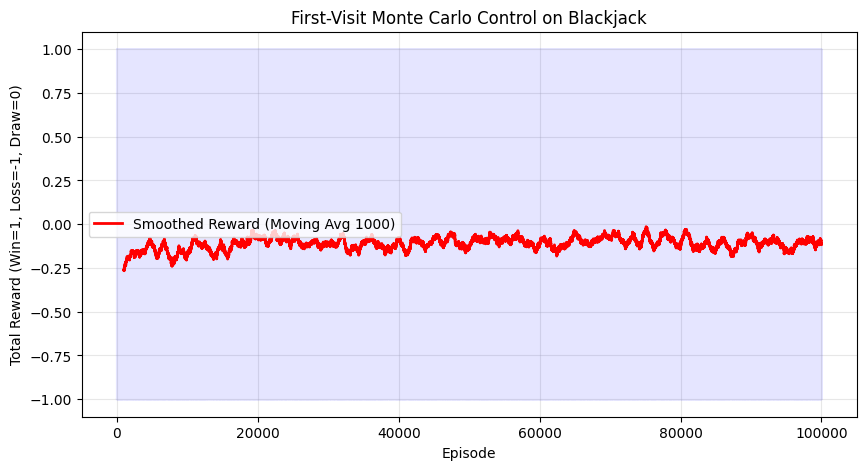

In [6]:
# ==========================================
# 4. Plot Learning Curve
# ==========================================
plt.figure(figsize=(10, 5))
window_size = 1000
smoothed_rewards = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')

plt.plot(episode_rewards, alpha=0.1, color='blue')
plt.plot(range(window_size - 1, num_episodes), smoothed_rewards, color='red', linewidth=2, label=f'Smoothed Reward (Moving Avg {window_size})')

plt.xlabel('Episode')
plt.ylabel('Total Reward (Win=1, Loss=-1, Draw=0)')
plt.title('First-Visit Monte Carlo Control on Blackjack')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

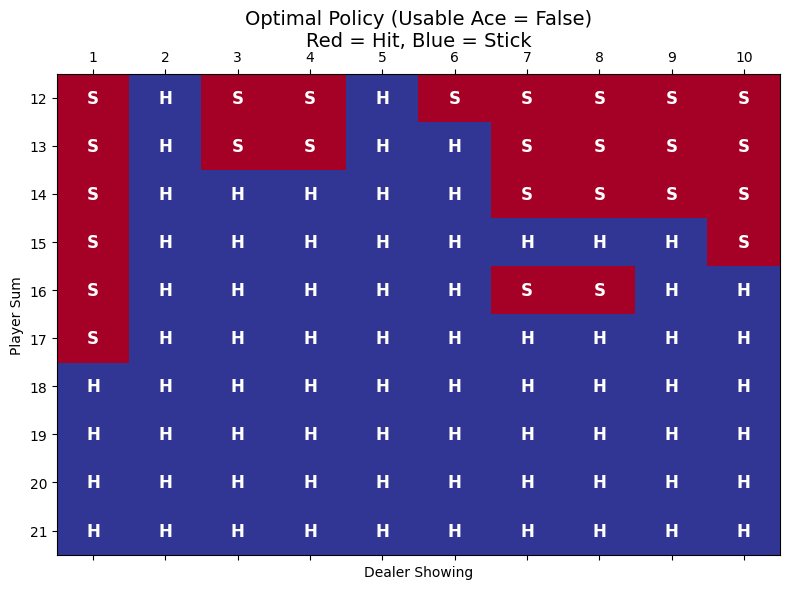

In [7]:
# ==========================================
# 5. Visualize the Learned Policy
# ==========================================
def plot_blackjack_policy(Q):
    """Plots the optimal policy for Usable Ace = False."""
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    # Create a grid of actions (0=Hit, 1=Stick)
    policy_grid = np.zeros((len(player_sums), len(dealer_cards)), dtype=int)

    for i, p_sum in enumerate(player_sums):
        for j, d_card in enumerate(dealer_cards):
            state = (p_sum, d_card, 0) # 0 means no usable ace
            if (state, 0) in Q or (state, 1) in Q:
                q_vals = [Q[(state, a)] for a in range(2)]
                policy_grid[i, j] = np.argmax(q_vals)
            else:
                policy_grid[i, j] = 0 # Default to Hit if unseen

    fig, ax = plt.subplots(figsize=(8, 6))
    # Use a custom colormap: 0 (Hit) = Red, 1 (Stick) = Blue
    cmap = plt.cm.RdYlBu_r
    cax = ax.matshow(policy_grid, cmap=cmap, vmin=0, vmax=1, aspect='auto')

    ax.set_title('Optimal Policy (Usable Ace = False)\nRed = Hit, Blue = Stick', pad=20, fontsize=14)
    ax.set_xlabel('Dealer Showing')
    ax.set_ylabel('Player Sum')

    ax.set_xticks(range(len(dealer_cards)))
    ax.set_xticklabels(dealer_cards)
    ax.set_yticks(range(len(player_sums)))
    ax.set_yticklabels(player_sums)

    # Add text annotations
    for (i, j), val in np.ndenumerate(policy_grid):
        text = 'H' if val == 0 else 'S'
        ax.text(j, i, text, ha='center', va='center', color='white', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_blackjack_policy(Q)